# HGTsfc (orography) differences across FM training datasets

Config: `ace-train-config-4deg-AIMIP-nc-sfno-fm-random-v2.yaml`

`HGTsfc` is a **static input forcing** (`stepper.step.config.in_names`). The FM train
loader pools ERA5 and three SHiELD (c96→4°) datasets. This notebook checks whether the
surface-height field they hand the model for the same grid cell agrees.

Companion to `coordinate_mismatch_report.md` (which covers the vertical `ak`/`bk` coord).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# GCS source paths (bucket root gs://vcm-ml-intermediate/).
# These back the /climate-default/... entries in the train_loader concat.
paths = {
    "ERA5":          "gs://vcm-ml-intermediate/2026-04-17-era5-4deg-8layer-daily-1940-2025/2026-03-19-era5-4deg-8layer-1940-2025.zarr",
    "SHiELD-amip":   "gs://vcm-ml-intermediate/2026-01-28-vertically-resolved-c96-4deg-daily-shield-amip-ensemble-dataset/ic_0001.zarr",
    "SHiELD-ramped": "gs://vcm-ml-intermediate/2026-06-08-vertically-resolved-c96-shield-ramped-climSST-random-CO2-ensemble-fme-dataset-4deg-daily/ramped-sst-1xCO2-random-perturbation.zarr",
    "SHiELD-som":    "gs://vcm-ml-intermediate/2026-06-08-vertically-resolved-4deg-daily-c96-shield-som-ensemble-fme-dataset/1xCO2-ic_0001.zarr",
}

In [2]:
# Load HGTsfc from each dataset. Field is static (no time dependence); take t=0 if a
# time dim exists. Keep one DataArray (ERA5) to reuse lat/lon for plotting.
fields = {}
ref_da = None
for name, p in paths.items():
    ds = xr.open_zarr(p, decode_times=False, chunks=None)
    h = ds["HGTsfc"]
    if "time" in h.dims:
        h = h.isel(time=0)
    fields[name] = h.values.astype(np.float64)
    if name == "ERA5":
        ref_da = h

# Grid coords (ERA5 uses latitude/longitude; SHiELD uses grid_yt/grid_xt, allclose).
lat_name = "latitude" if "latitude" in ref_da.coords else "lat"
lon_name = "longitude" if "longitude" in ref_da.coords else "lon"
lat = ref_da[lat_name].values
lon = ref_da[lon_name].values
print("grid", fields["ERA5"].shape, "| lat", lat.min(), lat.max(), "| lon", lon.min(), lon.max())

grid (45, 90) | lat -86.97178941704219 86.97178941704219 | lon 2.0 358.0


In [3]:
# Summary stats + pairwise differences.
print(f"{'dataset':14s} {'min':>9} {'max':>9} {'mean':>9}")
for name, arr in fields.items():
    print(f"{name:14s} {arr.min():9.2f} {arr.max():9.2f} {arr.mean():9.2f}")

print("\n|Δ| vs ERA5 (m):")
ref = fields["ERA5"]
for name, arr in fields.items():
    if name == "ERA5":
        continue
    d = np.abs(arr - ref)
    print(f"  {name:14s} max={d.max():8.2f} mean={d.mean():7.2f} rms={np.sqrt((d**2).mean()):7.2f}")

print("\nAmong SHiELD (expect 0 — shared topo):")
sh = [n for n in fields if n.startswith("SHiELD")]
for i in range(len(sh)):
    for j in range(i + 1, len(sh)):
        print(f"  {sh[i]} vs {sh[j]}: max|Δ|={np.abs(fields[sh[i]] - fields[sh[j]]).max():.3e}")

dataset              min       max      mean
ERA5              -17.46   5030.16    364.37
SHiELD-amip      -242.15   5247.12    365.70
SHiELD-ramped    -242.15   5247.12    365.70
SHiELD-som       -242.15   5247.12    365.70

|Δ| vs ERA5 (m):
  SHiELD-amip    max=  949.95 mean=  48.70 rms=  80.63
  SHiELD-ramped  max=  949.95 mean=  48.70 rms=  80.63
  SHiELD-som     max=  949.95 mean=  48.70 rms=  80.63

Among SHiELD (expect 0 — shared topo):
  SHiELD-amip vs SHiELD-ramped: max|Δ|=0.000e+00
  SHiELD-amip vs SHiELD-som: max|Δ|=0.000e+00
  SHiELD-ramped vs SHiELD-som: max|Δ|=0.000e+00


All three SHiELD datasets share one topography, so compare a single **SHiELD** field against **ERA5**.

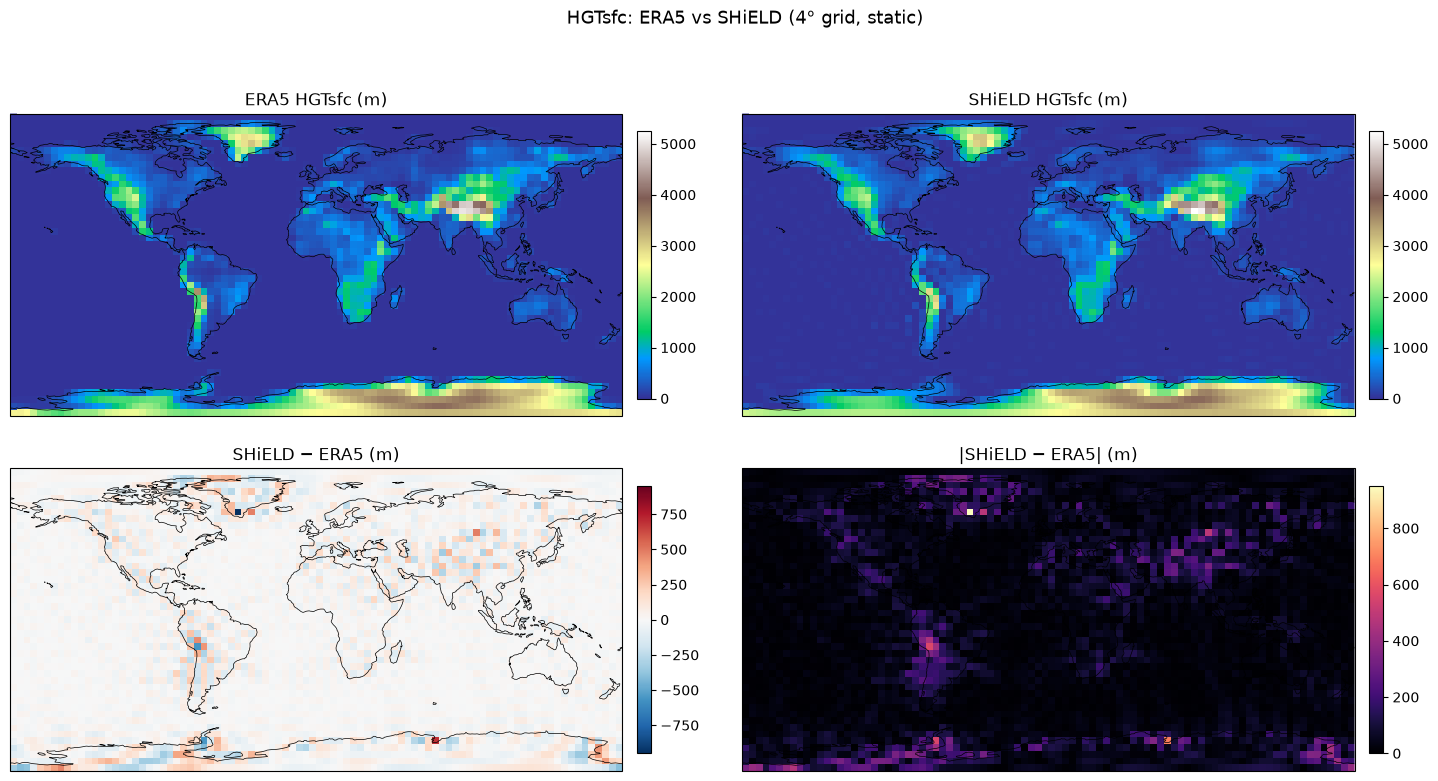

In [4]:
era5 = fields["ERA5"]
shield = fields["SHiELD-amip"]
diff = shield - era5  # SHiELD minus ERA5

hmax = max(era5.max(), shield.max())
dabs = np.abs(diff).max()
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(2, 2, figsize=(15, 8), subplot_kw={"projection": proj})

for ax, (title, data, cmap, vmin, vmax) in zip(
    axes.ravel(),
    [
        ("ERA5 HGTsfc (m)", era5, "terrain", 0, hmax),
        ("SHiELD HGTsfc (m)", shield, "terrain", 0, hmax),
        ("SHiELD − ERA5 (m)", diff, "RdBu_r", -dabs, dabs),
        ("|SHiELD − ERA5| (m)", np.abs(diff), "magma", 0, dabs),
    ],
):
    im = ax.pcolormesh(lon, lat, data, transform=proj, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.coastlines(linewidth=0.5)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

fig.suptitle("HGTsfc: ERA5 vs SHiELD (4° grid, static)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

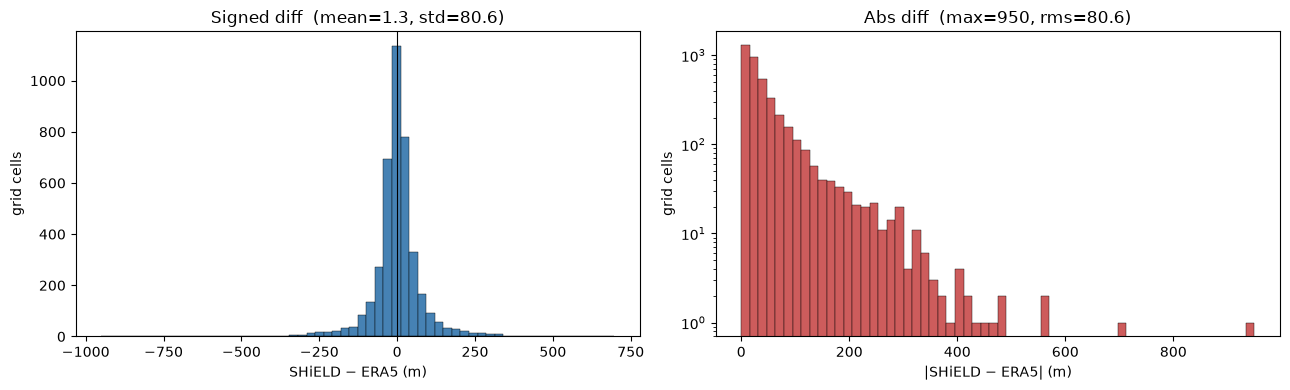

In [5]:
# Distribution of the per-cell difference.
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))

a0.hist(diff.ravel(), bins=60, color="steelblue", edgecolor="k", linewidth=0.3)
a0.axvline(0, color="k", lw=0.8)
a0.set_xlabel("SHiELD − ERA5 (m)"); a0.set_ylabel("grid cells")
a0.set_title(f"Signed diff  (mean={diff.mean():.1f}, std={diff.std():.1f})")

a1.hist(np.abs(diff).ravel(), bins=60, color="indianred", edgecolor="k", linewidth=0.3)
a1.set_xlabel("|SHiELD − ERA5| (m)"); a1.set_ylabel("grid cells")
a1.set_title(f"Abs diff  (max={np.abs(diff).max():.0f}, rms={np.sqrt((diff**2).mean()):.1f})")
a1.set_yscale("log")
fig.tight_layout()
plt.show()

In [6]:
# Top-10 grid cells by |diff| — where the topographies disagree most.
flat = np.abs(diff).ravel()
idx = np.argsort(flat)[::-1][:10]
ii, jj = np.unravel_index(idx, diff.shape)
print(f"{'lat':>7} {'lon':>7} {'ERA5':>9} {'SHiELD':>9} {'diff':>9}")
for i, j in zip(ii, jj):
    print(f"{lat[i]:7.1f} {lon[j]:7.1f} {era5[i, j]:9.1f} {shield[i, j]:9.1f} {diff[i, j]:9.1f}")

    lat     lon      ERA5    SHiELD      diff
   63.3   314.0    2316.0    1366.1    -950.0
  -71.2    70.0     297.5     994.9     697.5
  -15.8   290.0    3493.6    2929.6    -564.0
  -71.2   294.0    1152.2     596.9    -555.3
   51.4    94.0    1214.0    1698.4     484.4
   63.3   322.0       1.5     481.2     479.7
  -87.0   210.0    1686.9    2152.4     465.5
  -11.9   290.0     631.8    1083.3     451.5
  -75.2   166.0     218.8     650.2     431.3
  -75.2   294.0    1009.5     589.3    -420.2


## Takeaway

- The three SHiELD datasets are bit-identical in `HGTsfc` — one shared c96 topography.
- ERA5 vs SHiELD differ up to ~950 m locally (mean ~49 m, rms ~81 m), concentrated over
  steep terrain (Himalaya/Andes/Antarctic margins) where 4° regridding of model vs
  reanalysis surface height diverges.
- Because `HGTsfc` is a static input forcing pooled across both sources, the model sees
  two different surface heights for the same grid cell depending on the sample's origin.
  Harmonizing the orography (regrid one onto the other) removes this.